In [27]:
# 1. Imports, carga de credenciales desde .env y parámetros de descarga para todo el corredor

%pip install python-dotenv requests rasterio pandas --quiet

import os
import io
import json
import math
import tarfile
from pathlib import Path
from datetime import datetime, timedelta, timezone

import geopandas as gpd
import pandas as pd
import requests
from dotenv import load_dotenv

load_dotenv()

CLIENT_ID = os.getenv("CDSE_CLIENT_ID")
CLIENT_SECRET = os.getenv("CDSE_CLIENT_SECRET")

if not CLIENT_ID or not CLIENT_SECRET:
    raise ValueError("Faltan CDSE_CLIENT_ID y/o CDSE_CLIENT_SECRET en el .env")

CORRIDOR_ID = "soria_torralba"

INPUT_BLOCKS = Path(f"../outputs/{CORRIDOR_ID}_corridor_blocks_wgs84.geojson")
OUTPUT_BASE_DIR = Path("../outputs/ndvi_blocks")

DAYS_BACK = 30
MAX_CLOUD_COVER = 20
RESOLUTION_M = 10

TOKEN_URL = "https://identity.dataspace.copernicus.eu/auth/realms/CDSE/protocol/openid-connect/token"
PROCESS_URL = "https://sh.dataspace.copernicus.eu/api/v1/process"

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [28]:
# 2. Carga de los bloques del corredor y construcción dinámica de la ventana temporal

corridor = gpd.read_file(INPUT_BLOCKS)

date_to = datetime.now(timezone.utc)
date_from = date_to - timedelta(days=DAYS_BACK)

TIME_FROM = date_from.strftime("%Y-%m-%dT%H:%M:%SZ")
TIME_TO = date_to.strftime("%Y-%m-%dT%H:%M:%SZ")

print("Corredor:", CORRIDOR_ID)
print("Número total de bloques:", len(corridor))
print("Ventana temporal:")
print("from:", TIME_FROM)
print("to  :", TIME_TO)
print("Cloud coverage máximo:", MAX_CLOUD_COVER)
print("Resolución (m):", RESOLUTION_M)

Corredor: soria_torralba
Número total de bloques: 94
Ventana temporal:
from: 2026-04-05T13:25:19Z
to  : 2026-05-05T13:25:19Z
Cloud coverage máximo: 20
Resolución (m): 10


In [39]:
# 3. Definición del evalscript NDVI con mosaicking por TILE para capturar la fecha real de adquisición

evalscript_ndvi = """
//VERSION=3
function setup() {
  return {
    input: [{
      bands: ["B04", "B08", "dataMask"]
    }],
    output: {
      id: "default",
      bands: 1,
      sampleType: "FLOAT32"
    },
    mosaicking: "TILE"
  };
}

function updateOutputMetadata(scenes, inputMetadata, outputMetadata) {
  outputMetadata.userData = {
    tiles: scenes.tiles || []
  };
}

function evaluatePixel(samples) {
  let sample = samples[0];

  if (sample.dataMask === 0) {
    return [NaN];
  }

  let ndvi = (sample.B08 - sample.B04) / (sample.B08 + sample.B04);
  return [ndvi];
}
"""

print("Evalscript NDVI con metadata de tiles preparado")

Evalscript NDVI con metadata de tiles preparado


In [40]:
# 4. Autenticación OAuth contra CDSE / Sentinel Hub y obtención del access token

token_data = {
    "grant_type": "client_credentials",
    "client_id": CLIENT_ID,
    "client_secret": CLIENT_SECRET
}

token_response = requests.post(TOKEN_URL, data=token_data)
token_response.raise_for_status()

access_token = token_response.json()["access_token"]

headers = {
    "Content-Type": "application/json",
    "Authorization": f"Bearer {access_token}"
}

print("Token obtenido correctamente")

Token obtenido correctamente


In [43]:
# 5. Función de descarga del ráster NDVI y de los metadatos de adquisición para un bloque

def build_request_body(block_gdf, time_from, time_to, max_cloud_cover, resolution_m, evalscript):
    minx, miny, maxx, maxy = block_gdf.total_bounds
    bbox = [float(minx), float(miny), float(maxx), float(maxy)]

    block_metric = block_gdf.to_crs("EPSG:25830")
    minx_m, miny_m, maxx_m, maxy_m = block_metric.total_bounds

    width_m = maxx_m - minx_m
    height_m = maxy_m - miny_m

    width_px = math.ceil(width_m / resolution_m)
    height_px = math.ceil(height_m / resolution_m)

    request_body = {
        "input": {
            "bounds": {
                "bbox": bbox
            },
            "data": [
                {
                    "type": "sentinel-2-l2a",
                    "dataFilter": {
                        "timeRange": {
                            "from": time_from,
                            "to": time_to
                        },
                        "maxCloudCoverage": max_cloud_cover,
                        "mosaickingOrder": "mostRecent"
                    }
                }
            ]
        },
        "output": {
            "width": width_px,
            "height": height_px,
            "responses": [
                {
                    "identifier": "default",
                    "format": {
                        "type": "image/tiff"
                    }
                },
                {
                    "identifier": "userdata",
                    "format": {
                        "type": "application/json"
                    }
                }
            ]
        },
        "evalscript": evalscript
    }

    return request_body, width_px, height_px


def extract_capture_date(userdata):
    if not isinstance(userdata, dict):
        return None

    tiles = userdata.get("tiles", [])
    if not isinstance(tiles, list) or len(tiles) == 0:
        return None

    first_tile = tiles[0]
    if not isinstance(first_tile, dict):
        return None

    return first_tile.get("date")


def fetch_ndvi_block(block_gdf, headers, output_base_dir, process_url, time_from, time_to, max_cloud_cover, resolution_m, evalscript):
    segment_id = block_gdf.iloc[0]["segment_id"]

    request_body, width_px, height_px = build_request_body(
        block_gdf=block_gdf,
        time_from=time_from,
        time_to=time_to,
        max_cloud_cover=max_cloud_cover,
        resolution_m=resolution_m,
        evalscript=evalscript
    )

    tar_headers = headers.copy()
    tar_headers["Accept"] = "application/x-tar"

    response = requests.post(process_url, headers=tar_headers, json=request_body)
    response.raise_for_status()

    tif_bytes = None
    userdata = None

    with tarfile.open(fileobj=io.BytesIO(response.content), mode="r:*") as tar:
        for member in tar.getmembers():
            if not member.isfile():
                continue

            extracted = tar.extractfile(member)
            if extracted is None:
                continue

            if member.name.endswith(".tif") or member.name.endswith(".tiff"):
                tif_bytes = extracted.read()

            elif member.name.endswith("userdata.json"):
                userdata = json.load(extracted)

    if tif_bytes is None:
        raise ValueError(f"No se encontró ningún TIFF en la respuesta TAR para {segment_id}")

    if userdata is None:
        raise ValueError(f"No se encontró userdata.json en la respuesta TAR para {segment_id}")

    capture_date_raw = extract_capture_date(userdata)
    if capture_date_raw is None:
        raise ValueError(f"No se pudo extraer la fecha de captura para {segment_id}")

    capture_date = capture_date_raw[:10]
    output_dir = output_base_dir / CORRIDOR_ID / capture_date
    output_dir.mkdir(parents=True, exist_ok=True)

    output_tiff = output_dir / f"{segment_id}_ndvi.tif"
    output_meta = output_dir / f"{segment_id}_metadata.json"

    with open(output_tiff, "wb") as f:
        f.write(tif_bytes)

    with open(output_meta, "w", encoding="utf-8") as f:
        json.dump(userdata, f, ensure_ascii=False, indent=2)

    return {
        "segment_id": segment_id,
        "capture_date": capture_date,
        "status": "ok",
        "output_file": str(output_tiff),
        "metadata_file": str(output_meta),
        "width_px": width_px,
        "height_px": height_px,
        "error": None
    }

In [44]:
# 6. Descarga del NDVI para todos los bloques del corredor, ordenando los resultados por fecha real de captura

results = []

for idx in range(len(corridor)):
    block = corridor.iloc[[idx]].copy()
    segment_id = block.iloc[0]["segment_id"]

    try:
        result = fetch_ndvi_block(
            block_gdf=block,
            headers=headers,
            output_base_dir=OUTPUT_BASE_DIR,
            process_url=PROCESS_URL,
            time_from=TIME_FROM,
            time_to=TIME_TO,
            max_cloud_cover=MAX_CLOUD_COVER,
            resolution_m=RESOLUTION_M,
            evalscript=evalscript_ndvi
        )

        print(f"[OK] {segment_id} -> {result['capture_date']}")
        results.append(result)

    except Exception as e:
        print(f"[ERROR] {segment_id}: {e}")

        results.append({
            "segment_id": segment_id,
            "capture_date": None,
            "status": "error",
            "output_file": None,
            "metadata_file": None,
            "width_px": None,
            "height_px": None,
            "error": str(e)
        })

results_df = pd.DataFrame(results)

log_dir = OUTPUT_BASE_DIR / CORRIDOR_ID
log_dir.mkdir(parents=True, exist_ok=True)

log_file = log_dir / f"{CORRIDOR_ID}_download_log.csv"
results_df.to_csv(log_file, index=False)

print("\nProceso completado")
print("Bloques OK:", (results_df["status"] == "ok").sum())
print("Bloques ERROR:", (results_df["status"] == "error").sum())
print("Log guardado en:", log_file)

[OK] soria_torralba_km0_1 -> 2026-04-27
[OK] soria_torralba_km1_2 -> 2026-04-27
[OK] soria_torralba_km2_3 -> 2026-04-27
[OK] soria_torralba_km3_4 -> 2026-04-27
[OK] soria_torralba_km4_5 -> 2026-04-27
[OK] soria_torralba_km5_6 -> 2026-04-27
[OK] soria_torralba_km6_7 -> 2026-04-27
[OK] soria_torralba_km7_8 -> 2026-04-27
[OK] soria_torralba_km8_9 -> 2026-04-27
[OK] soria_torralba_km9_10 -> 2026-04-27
[OK] soria_torralba_km10_11 -> 2026-04-27
[OK] soria_torralba_km11_12 -> 2026-04-27
[OK] soria_torralba_km12_13 -> 2026-04-27
[OK] soria_torralba_km13_14 -> 2026-04-27
[OK] soria_torralba_km14_15 -> 2026-04-27
[OK] soria_torralba_km15_16 -> 2026-04-27
[OK] soria_torralba_km16_17 -> 2026-04-27
[OK] soria_torralba_km17_18 -> 2026-04-27
[OK] soria_torralba_km18_19 -> 2026-04-27
[OK] soria_torralba_km19_20 -> 2026-04-27
[OK] soria_torralba_km20_21 -> 2026-04-27
[OK] soria_torralba_km21_22 -> 2026-04-27
[OK] soria_torralba_km22_23 -> 2026-04-27
[OK] soria_torralba_km23_24 -> 2026-04-27
[OK] soria_

In [45]:
# 7. Comprobación final de la jerarquía de salida por fecha de captura (solo para validación manual)

corridor_root = OUTPUT_BASE_DIR / CORRIDOR_ID

date_dirs = sorted([p for p in corridor_root.iterdir() if p.is_dir()])

print("Directorio raíz:", corridor_root)
print("Fechas detectadas:", [p.name for p in date_dirs])
print("Número de carpetas de fecha:", len(date_dirs))

for date_dir in date_dirs:
    tifs = list(date_dir.glob("*_ndvi.tif"))
    print(f"{date_dir.name}: {len(tifs)} TIFF")

Directorio raíz: ..\outputs\ndvi_blocks\soria_torralba
Fechas detectadas: ['2026-04-22', '2026-04-27']
Número de carpetas de fecha: 2
2026-04-22: 29 TIFF
2026-04-27: 65 TIFF


Número total de TIFF encontrados: 94
Mostrando: ..\outputs\ndvi_blocks\soria_torralba\2026-04-22\soria_torralba_km65_66_ndvi.tif


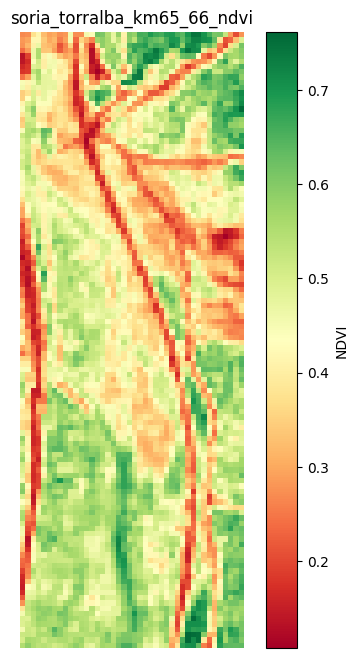

In [46]:
# 8. Comprobación visual rápida de un GeoTIFF descargado (solo para validación manual)

import numpy as np
import matplotlib.pyplot as plt
import rasterio

all_tifs = sorted((OUTPUT_BASE_DIR / CORRIDOR_ID).glob("*/*_ndvi.tif"))

print("Número total de TIFF encontrados:", len(all_tifs))

if all_tifs:
    sample_tif = all_tifs[0]
    print("Mostrando:", sample_tif)

    with rasterio.open(sample_tif) as src:
        arr = src.read(1)

    arr_plot = np.where(np.isfinite(arr), arr, np.nan)

    plt.figure(figsize=(6, 8))
    plt.imshow(arr_plot, cmap="RdYlGn")
    plt.colorbar(label="NDVI")
    plt.title(sample_tif.stem)
    plt.axis("off")
    plt.show()
else:
    print("No se han encontrado TIFF para visualizar")

In [48]:
# 9. Generación de manifest.csv y manifest.json con el inventario de bloques descargados

import json

corridor_root = OUTPUT_BASE_DIR / CORRIDOR_ID
corridor_root.mkdir(parents=True, exist_ok=True)

manifest_df = corridor[[
    "corridor_id",
    "segment_index",
    "segment_id",
    "start_km",
    "end_km",
    "length_m"
]].copy()

results_ok_df = results_df[results_df["status"] == "ok"].copy()

manifest_df = manifest_df.merge(
    results_ok_df[[
        "segment_id",
        "capture_date",
        "output_file",
        "metadata_file",
        "width_px",
        "height_px"
    ]],
    on="segment_id",
    how="inner"
)

manifest_df = manifest_df.sort_values("segment_index").reset_index(drop=True)

manifest_csv = corridor_root / "manifest.csv"
manifest_json = corridor_root / "manifest.json"

manifest_df.to_csv(manifest_csv, index=False)

manifest_records = manifest_df.to_dict(orient="records")
with open(manifest_json, "w", encoding="utf-8") as f:
    json.dump(manifest_records, f, ensure_ascii=False, indent=2)

print("Manifest generado correctamente")
print("CSV :", manifest_csv)
print("JSON:", manifest_json)
print("Número de registros:", len(manifest_df))

manifest_df.head()

Manifest generado correctamente
CSV : ..\outputs\ndvi_blocks\soria_torralba\manifest.csv
JSON: ..\outputs\ndvi_blocks\soria_torralba\manifest.json
Número de registros: 94


,corridor_id,segment_index,segment_id,start_km,end_km,length_m,capture_date,output_file,metadata_file,width_px,height_px
0,soria_torralba,1,soria_torralba_km0_1,0.0,1.0,1000.0,2026-04-27,..\outputs\ndvi_blocks\soria_torralba\2026-04-...,..\outputs\ndvi_blocks\soria_torralba\2026-04-...,47,108
1,soria_torralba,2,soria_torralba_km1_2,1.0,2.0,1000.0,2026-04-27,..\outputs\ndvi_blocks\soria_torralba\2026-04-...,..\outputs\ndvi_blocks\soria_torralba\2026-04-...,71,107
2,soria_torralba,3,soria_torralba_km2_3,2.0,3.0,1000.0,2026-04-27,..\outputs\ndvi_blocks\soria_torralba\2026-04-...,..\outputs\ndvi_blocks\soria_torralba\2026-04-...,65,109
3,soria_torralba,4,soria_torralba_km3_4,3.0,4.0,1000.0,2026-04-27,..\outputs\ndvi_blocks\soria_torralba\2026-04-...,..\outputs\ndvi_blocks\soria_torralba\2026-04-...,90,88
4,soria_torralba,5,soria_torralba_km4_5,4.0,5.0,1000.0,2026-04-27,..\outputs\ndvi_blocks\soria_torralba\2026-04-...,..\outputs\ndvi_blocks\soria_torralba\2026-04-...,95,79
